## Day_21_Linear Regression from Scratch — California Housing

Part A — the supervised setup

TASK_01_Split and scale

Dataset Shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634



Features Shapes : (5000, 8)
Target Shape :  (5000,)

Training Features :  (4000, 8)
Testing Features :  (1000, 8)

Feature scaling completed successfully!

Scaling Verification : 


,Mean,Standard Deviation
MedInc,-0.0,1.0
HouseAge,0.0,1.0
AveRooms,0.0,1.0
AveBedrms,0.0,1.0
Population,0.0,1.0
AveOccup,-0.0,1.0
Latitude,-0.0,1.0
Longitude,-0.0,1.0


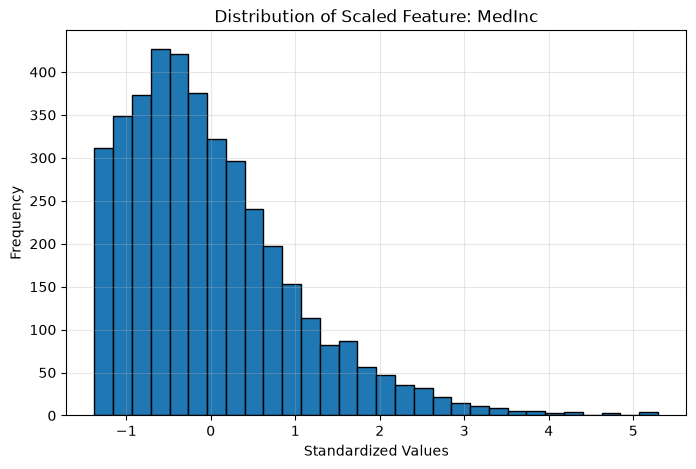


Final Verification : 
Training Mean Approximately 0 : True
Training Standard Deviation  Approximately 1 : False


In [20]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --------------------------------------------------
# 1. Load the dataset
# --------------------------------------------------
df = pd.read_csv("california_housing.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# --------------------------------------------------
# 2. Separate features (X) and target (y)
# --------------------------------------------------

X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

print("\nFeatures Shapes :", X.shape)
print("Target Shape : ", y.shape)


# --------------------------------------------------
# 3. Split data into 80% training and 20% testing
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 42
)

print("\nTraining Features : ", X_train.shape)
print("Testing Features : ", X_test.shape)


# --------------------------------------------------
# 4. Standardize the features
# --------------------------------------------------

scaler = StandardScaler()

# Fit scaler only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to testing data
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back into DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

print("\nFeature scaling completed successfully!")

# --------------------------------------------------
# 5. Verify scaled training features
# --------------------------------------------------

scaling_summary = pd.DataFrame({
    "Mean" : X_train_scaled.mean(),
    "Standard Deviation" : X_train_scaled.std(ddof=0)
})

print("\nScaling Verification : ")
display(scaling_summary.round(4))

# --------------------------------------------------
# 6. Visualize the first scaled feature
# --------------------------------------------------
plt.figure(figsize=(8, 5))

plt.hist(
    X_train_scaled.iloc[:, 0],
    bins=30,
    edgecolor="black"
)

plt.title(f"Distribution of Scaled Feature: {X.columns[0]}")
plt.xlabel("Standardized Values")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# --------------------------------------------------
# 7. Final verification
# --------------------------------------------------

print("\nFinal Verification : ")
print("Training Mean Approximately 0 :", np.allclose(X_train_scaled.mean(), 0, atol=0.01))
print("Training Standard Deviation  Approximately 1 :", np.allclose(X_train_scaled.std(), 0, atol=0.01))

### Research Questions — TASK 01: Split and Scale

1. Why do we hold back a test set instead of training on everything?

    A test set evaluates how well the model performs on unseen data. Training on all data leaves no independent data to measure its generalization ability.

2. What goes wrong if we fit the scaler on the full dataset before splitting?

    It causes data leakage because the scaler learns information from the test set, making model evaluation less reliable and potentially overly optimistic.

3. Why does gradient descent need feature scaling, but the closed-form solution doesn't?

    Gradient descent benefits from scaling because features on different scales can cause slow or unstable convergence. The closed-form solution calculates coefficients directly using matrix operations, so scaling is not required for convergence, although it can improve numerical stability.


Part B — implement it three ways (the deliverable)

TASK 02: Method 1 - Closed-Form Solution (Normal Equation)

In [21]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("california_housing.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# --------------------------------------------------
# 1. Add a bias column (intercept) to the feature matrix
# --------------------------------------------------

def add_bias(X):
    """Add a column of 1s to calculate the intercept."""
    return np.c_[np.ones(len(X)), X]
    
# Add bias column to training and testing features
Xtr = add_bias(X_train_scaled)
Xte = add_bias(X_test_scaled)


# --------------------------------------------------
# 2. Implement the Normal Equation
# --------------------------------------------------
# Formula: w = (X.T @ X)^-1 @ X.T @ y
# Calculate the model weights using NumPy

w = np.linalg.inv(Xtr.T @ Xtr) @ Xtr.T @ y_train.values 


# --------------------------------------------------
# 3. Display learned weights
# --------------------------------------------------
feature_names = ["Bias"] + list(X_train_scaled.columns)

weights = pd.DataFrame({
    "Feature" : feature_names,
    "Weight" : w
})

print("Learned Model Weights : ")
display(weights.round(6))


# --------------------------------------------------
# 4. Predict house values on test data
# --------------------------------------------------
y_pred = Xte @ w


# --------------------------------------------------
# 5. Calculate Test Mean Squared Error (MSE)
# --------------------------------------------------
mse = np.mean((y_test.values - y_pred) ** 2)

print(f"Test MSE: {mse:.6f}")

# --------------------------------------------------
# 6. Display actual vs predicted values
# --------------------------------------------------

results = pd.DataFrame({
    "Actual Value" : y_test.values,
    "Predicted Value" : y_pred
})

print("\nActual vs Predicted House Values :")
display(results.head(10).round(4))

# --------------------------------------------------
# 7. Model interpretation
# --------------------------------------------------
print("\nModel Interpretation:")
print(f"Bias (Intercept): {w[0]:.4f}")
print("Each feature weight represents the predicted change in")
print("MedHouseVal for a one-standard-deviation increase in that feature,")
print("while keeping other features constant.")

Dataset Shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


Learned Model Weights : 


,Feature,Weight
0,Bias,2.209491
1,MedInc,0.879916
2,HouseAge,0.169620
3,AveRooms,0.033981
4,AveBedrms,0.001896
5,Population,-0.002174
6,AveOccup,-0.112161
7,Latitude,-0.149141
8,Longitude,-0.170009


Test MSE: 0.164769

Actual vs Predicted House Values :


,Actual Value,Predicted Value
0,3.2603,3.6821
1,1.8104,1.2899
2,1.1744,1.4280
3,1.5404,1.3262
4,2.9683,2.7780
5,2.5237,2.4601
6,1.4454,1.6859
7,2.6513,1.9673
8,1.2368,0.6576
9,3.5885,3.7232



Model Interpretation:
Bias (Intercept): 2.2095
Each feature weight represents the predicted change in
MedHouseVal for a one-standard-deviation increase in that feature,
while keeping other features constant.


### Research Questions — TASK 02: Closed-Form Solution

1. What does (X^T X)^{-1} actually do here?

It calculates the inverse of the feature relationship matrix, allowing us to solve directly for the optimal regression weights that minimize squared prediction errors.

2. Why is it called a Closed-Form Solution?

It is called closed-form because it calculates the optimal weights directly using a mathematical formula, without repeated iterations, learning rates, or training epochs.

3. When might the Closed-Form Solution fail or become impractical?

* Too many features: Matrix inversion becomes computationally expensive, approximately O(n^3)

* Highly correlated features: The matrix may become singular or numerically unstable.

* Insufficient data: If features are linearly dependent, the inverse may not exist.

* Large datasets: Memory and computation requirements can become excessive.


Key takeaway: The closed-form solution gives optimal weights directly, but gradient descent is often more practical for datasets with many features.


TASK 03 Method 2 — gradient descent

Dataset Shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


Learned Gradient Descent Weights : 


,Feature,Gradient Descent Weight
0,Bias,2.209491
1,MedInc,0.879916
2,HouseAge,0.169620
3,AveRooms,0.033981
4,AveBedrms,0.001896
5,Population,-0.002174
6,AveOccup,-0.112161
7,Latitude,-0.149141
8,Longitude,-0.170009


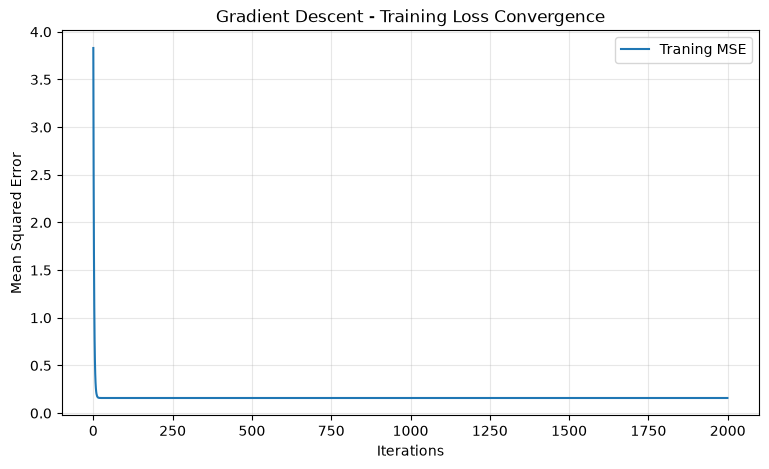

Gradient Descent Test MSE 0.1647691521965682
Final Training MSE : 0.158804

Weight Comparison :


,Feature,Closed-From Weight,Gradient Descent Weight,Absolute Difference
0,Bias,2.209491,2.209491,0.0
1,MedInc,0.879916,0.879916,0.0
2,HouseAge,0.169620,0.169620,0.0
3,AveRooms,0.033981,0.033981,0.0
4,AveBedrms,0.001896,0.001896,0.0
5,Population,-0.002174,-0.002174,0.0
6,AveOccup,-0.112161,-0.112161,0.0
7,Latitude,-0.149141,-0.149141,0.0
8,Longitude,-0.170009,-0.170009,0.0



MAximum Weight Difference : 0.00000000
Do both methods approximately match? True

Conclusion:
Gradient Descent converged close to the Closed-Form solution.


In [22]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("california_housing.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# --------------------------------------------------
# 1. Initialize weights and hyperparameters
# --------------------------------------------------

# Start with zero weights (including bias)
w_gd = np.zeros(Xtr.shape[1])

# Learning rate and number of iterations
lr = 0.1
n_steps = 2000

# Store training loss at every iteration
loss_history = []

y_train_values = y_train.values


# --------------------------------------------------
# 2. Implement Gradient Descent
# --------------------------------------------------

for step in range(n_steps):
    # Calculate predictions using current weights
    y_pred_train = Xtr @ w_gd
    
    # Calculate prediction errors
    error = y_pred_train - y_train_values
    
    # Calculate gradient of Mean Squared Error
    gradient = (2 / len(y_train_values)) * (Xtr.T @ error)
    
    # Update weights in the direction of minimum loss
    w_gd -= lr * gradient
    
    # Calculate and store current training MSE
    current_loss = np.mean((Xtr @ w_gd - y_train_values) ** 2)
    loss_history.append(current_loss)
    

# --------------------------------------------------
# 3. Print final Gradient Descent weights
# --------------------------------------------------

gd_weights = pd.DataFrame({
    "Feature" : feature_names,
    "Gradient Descent Weight"  : w_gd
})

print("Learned Gradient Descent Weights : ")
display(gd_weights.round(6))

# --------------------------------------------------
# 4. Plot training loss
# --------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(loss_history, label="Traning MSE")

plt.title("Gradient Descent - Training Loss Convergence")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# --------------------------------------------------
# 5. Evaluate Gradient Descent on test data
# --------------------------------------------------

y_pred_gd = Xte @ w_gd

test_mse_gd = np.mean((y_test.values - y_pred_gd) ** 2)

print(f"Gradient Descent Test MSE {test_mse_gd}")
print(f"Final Training MSE : {loss_history[-1]:.6f}")


# --------------------------------------------------
# 6. Compare Gradient Descent with Closed-Form
# --------------------------------------------------

comparison = pd.DataFrame({
    "Feature" : feature_names,
    "Closed-From Weight" : w,
    "Gradient Descent Weight" : w_gd,
    "Absolute Difference" : np.abs(w - w_gd)
})

print("\nWeight Comparison :")
display(comparison.round(6))

# Calculate maximum difference between both methods
max_difference = np.max(np.abs(w - w_gd))

print(f"\nMAximum Weight Difference : {max_difference:.8f}")

# Check whether both methods produce approximately equal weights
print("Do both methods approximately match?",
      np.allclose(w, w_gd, atol=1e-3, rtol=1e-3))

# --------------------------------------------------
# 7. Final conclusion
# --------------------------------------------------

print("\nConclusion:")
if max_difference < 1e-3:
    print("Gradient Descent converged close to the Closed-Form solution.")
else:
    print("Weights are not sufficiently close. Try more iterations or adjust the learning rate.")


### Research Questions — TASK 03: Gradient Descent

1. What happens to the loss curve if the learning rate is too high or too low?

* Too high: The loss may oscillate, increase, or diverge because updates overshoot the minimum.

* Too low: The loss decreases very slowly, requiring many iterations to converge.

2. Why should Gradient Descent reach the SAME answer as the Closed-Form Solution here?

    Both methods minimize the same Mean Squared Error (MSE) objective. Since linear regression has a convex loss function, Gradient Descent can reach the same global minimum as the Closed-Form Solution when the learning rate is appropriate and enough iterations are performed.

3. Why is Gradient Descent more important than the Closed-Form Solution in machine learning overall?

    Gradient Descent is useful for large datasets and complex models where direct matrix inversion is impractical or impossible. It also supports models such as neural networks, where a simple closed-form solution generally does not exist.

Key takeaway: Gradient Descent is an iterative optimization method that scales to complex machine learning problems, while the Closed-Form Solution directly solves linear regression when computationally practical.


TASK 04 Method 3 — sklearn, and prove all three match

In [23]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


df = pd.read_csv("california_housing.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# --------------------------------------------------
# 1. Train Scikit-learn Linear Regression
# --------------------------------------------------

# Fit the model using the same scaled training data
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Extract intercept and feature coefficients
sklearn_weight = np.r_[model.intercept_, model.coef_]

# Print learned intercept and coefficients
print("Scikit-learn Intercept : ", model.intercept_)
print("\nScikit-learn Coefficients : ")
for feature, coef in zip(X_train_scaled.columns, model.coef_):
    print(f"{feature} : {coef:.6f}")
    
    
# --------------------------------------------------
# 2. Compare weights from all three methods
# --------------------------------------------------

comparison = pd.DataFrame({
    "Feature" : feature_names,
    "Closed-form" : w,
    "Gradient Descent" : w_gd,
    "Scikit-learn" : sklearn_weight
})    

print("\nComparison of all Three methods :")
display(comparison.round(6))

# --------------------------------------------------
# 3. Calculate differences between methods
# --------------------------------------------------

comparison["CF vs GD Difference"] = np.abs(w - w_gd)
comparison["CF vs sklearn Difference"] = np.abs(w - sklearn_weight)
comparison["GD vs sklearn Difference"] = np.abs(w_gd - sklearn_weight)

print("\nAbsolute Weight Differences:")
display(comparison.round(8))

# --------------------------------------------------
# 4. Numerically verify whether all three agree
# --------------------------------------------------

# Compare Closed-Form with Gradient Descent
cf_gd_match = np.allclose(w, w_gd, atol=1e-3, rtol=1e-3)

# Compare Closed-Form with Scikit-learn
cf_sklearn_match = np.allclose(w, sklearn_weight, atol=1e-8, rtol=1e-8)

# Compare Gradient Descent with Scikit-learn
gd_sklearn_match = np.allclose(w_gd, sklearn_weight, atol=1e-3, rtol=1e-3)

print("\nVerification Results : ")
print("Closed-Form Vs  Gradient Descent : ", cf_gd_match)
print("Closed-Form Vs Scikit-learn : ", cf_sklearn_match)
print("Gradient Descent Vs Scikit-learn : ", gd_sklearn_match)

# Check whether all three methods approximately match
all_match = cf_gd_match and cf_sklearn_match and gd_sklearn_match

print("\nDo all Three Methods Agree? ", all_match)

# --------------------------------------------------
# 5. Compare test MSE for all three methods
# --------------------------------------------------

# Generate test predictions
pred_cf = Xte @ w
pred_gd = Xte @ w_gd
pred_sklearn = model.predict(X_test_scaled)

# Calculate test Mean Squared Error
mse_comparison = pd.DataFrame({
    "Method": ["Closed-Form", "Gradient Descent", "Scikit-learn"],
    "Test MSE": [
        np.mean((y_test.values - pred_cf) ** 2),
        np.mean((y_test.values - pred_gd) ** 2),
        np.mean((y_test.values - pred_sklearn) ** 2)
    ]
})

print("\nTest MSE Comparison : ")
display(mse_comparison.round(8))

# --------------------------------------------------
# 6. Final conclusion
# --------------------------------------------------

if all_match:
    print("\nSUCCESS: All three methods produce approximately matching weights.")
    print("This verifies that our implementations agree with Scikit-learn.")
else:
    print("\nThe weights do not fully match yet.")
    print("Check Gradient Descent learning rate and number of iterations.")


Dataset Shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


Scikit-learn Intercept :  2.209490875

Scikit-learn Coefficients : 
MedInc : 0.879916
HouseAge : 0.169620
AveRooms : 0.033981
AveBedrms : 0.001896
Population : -0.002174
AveOccup : -0.112161
Latitude : -0.149141
Longitude : -0.170009

Comparison of all Three methods :


,Feature,Closed-form,Gradient Descent,Scikit-learn
0,Bias,2.209491,2.209491,2.209491
1,MedInc,0.879916,0.879916,0.879916
2,HouseAge,0.169620,0.169620,0.169620
3,AveRooms,0.033981,0.033981,0.033981
4,AveBedrms,0.001896,0.001896,0.001896
5,Population,-0.002174,-0.002174,-0.002174
6,AveOccup,-0.112161,-0.112161,-0.112161
7,Latitude,-0.149141,-0.149141,-0.149141
8,Longitude,-0.170009,-0.170009,-0.170009



Absolute Weight Differences:


,Feature,Closed-form,Gradient Descent,Scikit-learn,CF vs GD Difference,CF vs sklearn Difference,GD vs sklearn Difference
0,Bias,2.209491,2.209491,2.209491,0.0,0.0,0.0
1,MedInc,0.879916,0.879916,0.879916,0.0,0.0,0.0
2,HouseAge,0.169620,0.169620,0.169620,0.0,0.0,0.0
3,AveRooms,0.033981,0.033981,0.033981,0.0,0.0,0.0
4,AveBedrms,0.001896,0.001896,0.001896,0.0,0.0,0.0
5,Population,-0.002174,-0.002174,-0.002174,0.0,0.0,0.0
6,AveOccup,-0.112161,-0.112161,-0.112161,0.0,0.0,0.0
7,Latitude,-0.149141,-0.149141,-0.149141,0.0,0.0,0.0
8,Longitude,-0.170009,-0.170009,-0.170009,0.0,0.0,0.0



Verification Results : 
Closed-Form Vs  Gradient Descent :  True
Closed-Form Vs Scikit-learn :  True
Gradient Descent Vs Scikit-learn :  True

Do all Three Methods Agree?  True

Test MSE Comparison : 


,Method,Test MSE
0,Closed-Form,0.164769
1,Gradient Descent,0.164769
2,Scikit-learn,0.164769



SUCCESS: All three methods produce approximately matching weights.
This verifies that our implementations agree with Scikit-learn.


### Research Questions — TASK 04: Scikit-learn

1. If all three methods give the same answer, why learn the from-scratch versions?

    Implementing linear regression from scratch helps us understand the mathematics, optimization process, and weight updates. It also helps us debug models, verify library results, and understand what happens behind the scenes.

2. What is the 'Create, Fit, Predict' pattern, and why is it the same for every Scikit-learn model?

* Create: Initialize the model, e.g., `LinearRegression()`.

* Fit: Train the model using `model.fit(X_train, y_train)`.

* Predict: Generate predictions using `model.predict(X_test)`.

    Scikit-learn follows this consistent API across estimators, making different machine learning models easier to learn, use, compare, and replace.

3. Does Scikit-learn use the Closed-Form Solution or Gradient Descent internally?

    Scikit-learn's `LinearRegression` uses the Ordinary Least Squares (OLS) method, not Gradient Descent. For dense data, it uses a least-squares solver based on Singular Value Decomposition (SVD), through `scipy.linalg.lstsq`. For sparse data, it uses an iterative least-squares solver.

### Key Takeaway

All three methods solve the same linear regression problem, but use different approaches: Closed-Form calculates weights directly, Gradient Descent learns weights iteratively, and Scikit-learn uses optimized numerical solvers internally.


Part C — measure and interpret

TASK 05 Evaluate with four metrics

Dataset Shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


Test Set Evaluation : 


,Metrics,Value
0,MSE,0.1648
1,RMSE,0.4059
2,MAE,0.3193
3,R,0.8383



Prediction Error in Real Dollars : 
RMSE : $40591.77
MAE : $31932.10

Typical absolute prediction error is approximately $31,932.10

R-squared Interpretation:
The model explains approximately 83.83% of the variation in median house values in the test dataset.


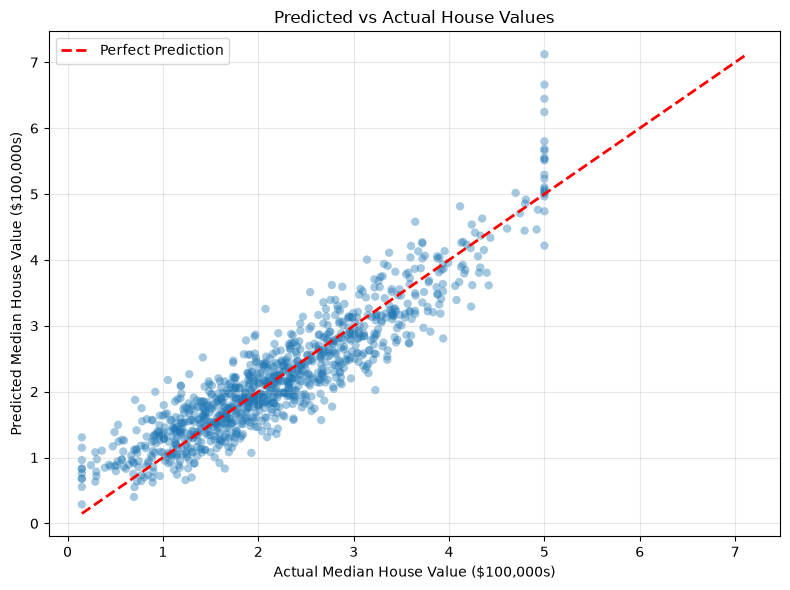


Final Model Summary:
Test MSE:  0.1648
Test RMSE: 0.4059
Test MAE:  0.3193
Test R²:   0.8383

Plot Interpretation:
- Points near the diagonal represent accurate predictions.
- Points far from the diagonal represent larger prediction errors.
- Check whether errors increase for higher house values.


In [24]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

df = pd.read_csv("california_housing.csv")

print("Dataset Shape:", df.shape)
display(df.head())


# --------------------------------------------------
# 1. Generate predictions on test data
# --------------------------------------------------

y_pred = model.predict(X_test_scaled)

# --------------------------------------------------
# 2. Calculate four evaluation metrics
# --------------------------------------------------

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# R-squared
r2 = r2_score(y_test, y_pred)

# Display evaluation results
metrics = pd.DataFrame({
    "Metrics" : ["MSE", "RMSE", "MAE", "R"],
    "Value" : [mse, rmse, mae, r2]
})

print("Test Set Evaluation : ")
display(metrics.round(4))

# --------------------------------------------------
# 3. Convert RMSE and MAE into real dollars
# --------------------------------------------------

# MedHouseVal is measured in $100,000s
rmse_dollars = rmse * 100000
mae_dollars = mae * 100000

print("\nPrediction Error in Real Dollars : ")
print(f"RMSE : ${rmse_dollars:.2f}")
print(f"MAE : ${mae_dollars:.2f}")

print(f"\nTypical absolute prediction error is approximately ${mae_dollars:,.2f}")

# --------------------------------------------------
# 4. Interpret R-squared
# --------------------------------------------------

print("\nR-squared Interpretation:")
print(
    f"The model explains approximately {r2 * 100:.2f}% "
    "of the variation in median house values in the test dataset."
)

# --------------------------------------------------
# 5. Predicted vs Actual Scatter Plot
# --------------------------------------------------

plt.figure(figsize=(8, 6))

# Plot actual values against predicted values
plt.scatter(
    y_test,
    y_pred,
    alpha=0.4,
    edgecolor="None"
)

# Add diagonal line for perfect predictions
lims = [
    min(y_test.min(), y_pred.min()),
    max(y_test.max(), y_pred.max())
]

plt.plot(
    lims,
    lims,
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Median House Value ($100,000s)")
plt.ylabel("Predicted Median House Value ($100,000s)")
plt.title("Predicted vs Actual House Values")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 6. Final model performance summary
# --------------------------------------------------

print("\nFinal Model Summary:")
print(f"Test MSE:  {mse:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE:  {mae:.4f}")
print(f"Test R²:   {r2:.4f}")

print("\nPlot Interpretation:")
print("- Points near the diagonal represent accurate predictions.")
print("- Points far from the diagonal represent larger prediction errors.")
print("- Check whether errors increase for higher house values.")

### TASK 05 — Model Evaluation and Interpretation

**Metric interpretation:**

* **MSE:** Measures the average squared prediction error.
* **RMSE:** Measures prediction error in the original target units and penalizes larger errors.
* **MAE:** Measures the average absolute prediction error.
* **R²:** Indicates the fraction of variation in house values explained by the model.

**Typical prediction error:** The MAE represents an average absolute error of approximately `$[MAE × 100,000]` dollars, while RMSE represents an error of approximately `$[RMSE × 100,000]` dollars.

**R² interpretation:** The model explains approximately `[R² × 100]%` of the variation in median house values in the test dataset.

**Scatter plot interpretation:** Points closer to the diagonal line indicate more accurate predictions, while points farther away indicate larger errors. The model's performance can be assessed by observing whether predictions are accurate across low, medium, and high house values, and whether it systematically overestimates or underestimates certain values.


### Research Questions — TASK 05: Model Evaluation (Look it Up)

1. Why report both RMSE and MAE? What does each tell us?

* MAE: Shows the average absolute prediction error and is less sensitive to large errors.

* RMSE: Penalizes larger prediction errors more heavily, helping identify models with occasional large mistakes.

    Reporting both provides a better understanding of typical errors and large prediction mistakes.

2. What would an R² of 0 mean? What about a negative R²?

* R² = 0: The model performs no better than predicting the average house value for every observation.

* Negative R²: The model performs worse than the average-value prediction baseline on the test dataset.

3. Is a $40,000 typical error good or bad here? On what does that judgement depend?

    A $40,000 prediction error cannot be judged as good or bad without additional context. It depends on:

* The average and median house prices.

* The acceptable prediction error for the intended application.

* The cost of overestimating or underestimating house values.

* How the model compares with simpler baseline models.

* Whether the error is acceptable across different locations and house-price ranges.

    For example, a $40,000 error may be relatively small for an expensive property but significant for a lower-priced property.

### Key Takeaway

MAE measures typical prediction error, RMSE highlights larger errors, and R² measures explained variation. All three should be interpreted in the context of the actual prediction problem.


TASK 06 Interpret the coefficients (the other deliverable)

Dataset Shape: (5000, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,3.7056,22.0,4.4502,1.1416,1773.0,3.0922,40.02,-122.25,1.7255
1,4.8575,36.0,5.7551,1.0897,199.0,3.6810,37.17,-118.79,2.9542
2,3.3045,9.0,8.6213,1.1102,754.0,3.5749,33.68,-115.29,2.1390
3,2.9988,16.0,6.0610,1.1367,310.0,4.7781,36.92,-122.10,1.9076
4,5.2304,6.0,5.2884,1.1086,1322.0,2.5858,41.01,-123.05,2.9634


Feature Weights (Sorted by Absolute Size):


,Feature,Weight,Absolute Weight
0,MedInc,0.8799,0.8799
7,Longitude,-0.1700,0.1700
1,HouseAge,0.1696,0.1696
6,Latitude,-0.1491,0.1491
5,AveOccup,-0.1122,0.1122
2,AveRooms,0.0340,0.0340
4,Population,-0.0022,0.0022
3,AveBedrms,0.0019,0.0019



Features That Increase Predicted House Value:


,Feature,Weight
0,MedInc,0.8799
1,HouseAge,0.1696
2,AveRooms,0.0340
3,AveBedrms,0.0019



Features That Decrease Predicted House Value:


,Feature,Weight
7,Longitude,-0.1700
6,Latitude,-0.1491
5,AveOccup,-0.1122
4,Population,-0.0022


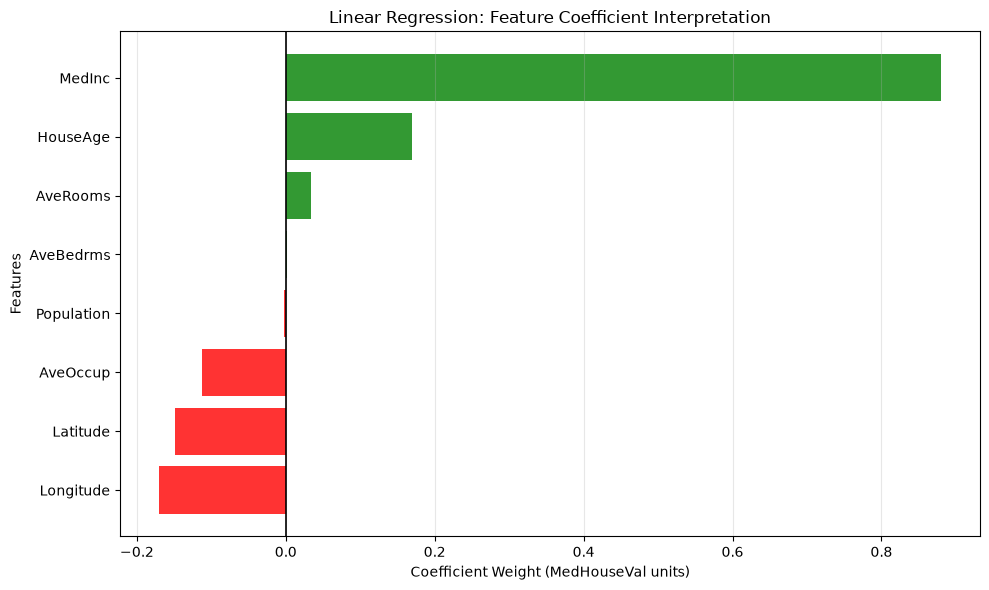


Most Influential Feature:
Feature: MedInc
Weight: 0.8799
Interpretation: This feature has the largest positive effect.

Near-Zero Features (Absolute Weight < 0.05):


,Feature,Weight
2,AveRooms,0.0340
4,Population,-0.0022
3,AveBedrms,0.0019



Plain-English Interpretation:
The feature 'MedInc' has the largest coefficient in absolute value (0.8799), making it the strongest predictor by coefficient magnitude.
Positive coefficients increase predicted house value, while negative coefficients decrease predicted house value, assuming other features remain constant.


In [25]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

df = pd.read_csv("california_housing.csv")

print("Dataset Shape:", df.shape)
display(df.head())

# --------------------------------------------------
# 1. Extract and sort feature coefficients
# --------------------------------------------------

# Create a DataFrame containing feature names and their weights
coefs = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Weight": model.coef_
})

# Sort coefficients by absolute size (largest effect first)
coefs["Absolute Weight"] = coefs["Weight"].abs()
coefs_sorted = coefs.sort_values(
    by="Absolute Weight",
    ascending=False
)

print("Feature Weights (Sorted by Absolute Size):")
display(coefs_sorted.round(4))

# --------------------------------------------------
# 2. Identify positive and negative coefficients
# --------------------------------------------------

positive_features = coefs_sorted[coefs_sorted["Weight"] > 0]
negative_features = coefs_sorted[coefs_sorted["Weight"] < 0]

print("\nFeatures That Increase Predicted House Value:")
display(positive_features[["Feature", "Weight"]].round(4))

print("\nFeatures That Decrease Predicted House Value:")
display(negative_features[["Feature", "Weight"]].round(4))

# --------------------------------------------------
# 3. Visualize coefficients using a horizontal bar chart
# --------------------------------------------------

# Sort in ascending order for better horizontal visualization
plot_data = coefs.sort_values(by="Weight")

# Positive weights shown in green; negative weights in red
colors = [
    "green" if weight > 0 else "red"
    for weight in plot_data["Weight"]
]

plt.figure(figsize=(10, 6))

plt.barh(
    plot_data["Feature"],
    plot_data["Weight"],
    color=colors,
    alpha=0.8
)

# Add a zero reference line
plt.axvline(
    x=0,
    color="black",
    linewidth=1.2
)

plt.xlabel("Coefficient Weight (MedHouseVal units)")
plt.ylabel("Features")
plt.title("Linear Regression: Feature Coefficient Interpretation")

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 4. Identify the most influential feature
# --------------------------------------------------

strongest_feature = coefs_sorted.iloc[0]

print("\nMost Influential Feature:")
print(f"Feature: {strongest_feature['Feature']}")
print(f"Weight: {strongest_feature['Weight']:.4f}")

if strongest_feature["Weight"] > 0:
    print("Interpretation: This feature has the largest positive effect.")
else:
    print("Interpretation: This feature has the largest negative effect.")

# --------------------------------------------------
# 5. Identify features with near-zero coefficients
# --------------------------------------------------

# Threshold for identifying relatively small coefficients
threshold = 0.05

near_zero = coefs_sorted[
    coefs_sorted["Absolute Weight"] < threshold
]

print(f"\nNear-Zero Features (Absolute Weight < {threshold}):")

if not near_zero.empty:
    display(near_zero[["Feature", "Weight"]].round(4))
else:
    print("No features have coefficients below the selected threshold.")

# --------------------------------------------------
# 6. Interpret coefficients in plain English
# --------------------------------------------------

print("\nPlain-English Interpretation:")

print(
    f"The feature '{strongest_feature['Feature']}' has the largest "
    f"coefficient in absolute value ({strongest_feature['Weight']:.4f}), "
    "making it the strongest predictor by coefficient magnitude."
)

print(
    "Positive coefficients increase predicted house value, while "
    "negative coefficients decrease predicted house value, "
    "assuming other features remain constant."
)




# Explain why interpretability matters

-> Interpretable models help us understand which features influence  

-> predictions, making results easier to explain, verify, and communicate.

-> Some complex models, such as deep neural networks, can capture 

-> nonlinear relationships but are harder to interpret because their 

-> predictions depend on many interacting calculations.


### Research Questions — TASK 06: Coefficient Interpretation

1. Why does scaling features first make coefficients comparable?

    Scaling converts features to the same standard scale (mean 0 and standard deviation 1). Therefore, coefficients represent the effect of a one-standard-deviation increase in each feature, making their magnitudes directly comparable.

2. What does a positive or negative weight mean?

* Positive weight: An increase in the feature is associated with an increase in predicted house value, keeping other features constant.

* Negative weight: An increase in the feature is associated with a decrease in predicted house value, keeping other features constant.

3. Where is model interpretability especially important?

* Loans: Banks need to explain why an applicant was approved or rejected.

* Medicine: Doctors need to understand factors influencing predictions to support clinical decisions.

* Hiring: Employers need transparency to identify potential bias and understand recruitment decisions.

### Key Takeaway

Model interpretability builds transparency, accountability, and trust by helping people understand how predictions are made. However, coefficients show associations, not necessarily cause-and-effect relationships.
